# AP 155 Lab Exercise
---
## Exercise 4
: Derivatives

_Instructions_: 
- **Output 1: Finite Difference** Functions and plots of finite-difference methods
- **Output 2: Harmonic Oscillator** Error analysis plot of finite-difference methods.
  
### Student Information
- _Full Name (Last Name, First Name)_: Refuerzo, Paul Adam
- _Student No._: 2024-09465
- _Section_: WX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1G9tPPcyMUag91g_R02O0wsGYPiZWy5Nn/view?usp=drive_link) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Problem 1

![1](Problem_1.png)
Figure 1. Numerical and analytical differentiation

The three subplots show the numerical values using three different formulas against the analytical value. The plot for the forward (backward) difference formula is slightly skewed left (right) relative to the analytical plot. The central difference has the least deviation for this particular function around the maxima at x = 0.

### Problem 2

![1](Problem_2.png)
Figure 2. Absolute error in numerical differentiation methods at different t values

The four subplots show the absolute error of the three numerical methods at varying h for some values of t. It shows that for certain values of t, the graphs resemble the predicted dependence of $\mathcal{O}(n)$ for the forward and backward difference and $\mathcal{O}(n^2)$ for the central difference. This is more apparent for different values of t for the different formulas. Notably, the error plots of the forward and backward differences interchange at certain values as shown in figure 2. Also, the error for the central difference becomes very low at t values close to 0 and $\pi$, which are critical points of the given function. These observations match the results in figure 1 where the central difference has small error close to the critical point x=0 and the forward and backward differences being skewed the opposite way. 


---
## Section 2: Code

### Problem 1: Finite Difference

Let $$f(x) = 1+\frac{1}{2}\tanh(2x)$$

**(a)** Create functions that take as input an array or list of points corresponding to a mathematical function and output the derivative using **(a.1)** forward-difference, **(a.2)** backward-difference, and **(a.3)** central-difference methods.

In [2]:
import numpy as np

def f(x):
    y = 1 + (np.tanh(2*x) / 2)
    return y

# a.1
def for_diff(f, x, h):
    fd = (f(x+h) - f(x)) / h
    return fd

# a.2
def back_diff(f, x, h):
    bd = (f(x) - f(x-h)) / h
    return bd
# a.3
def cen_diff(f, x, h):
    cd = (f(x+(h/2)) - f(x-(h/2))) / h
    return cd

**(b)** Calculate an analytic formula for the derivative. Make three subplots for the derivative of $f'(x)$, one for each method and the analytic answer on the same plots. Plot the exact answer (use `numpy`) as lines and the numerical one as dots. Describe how the two results compare. Use `plt.subplots`

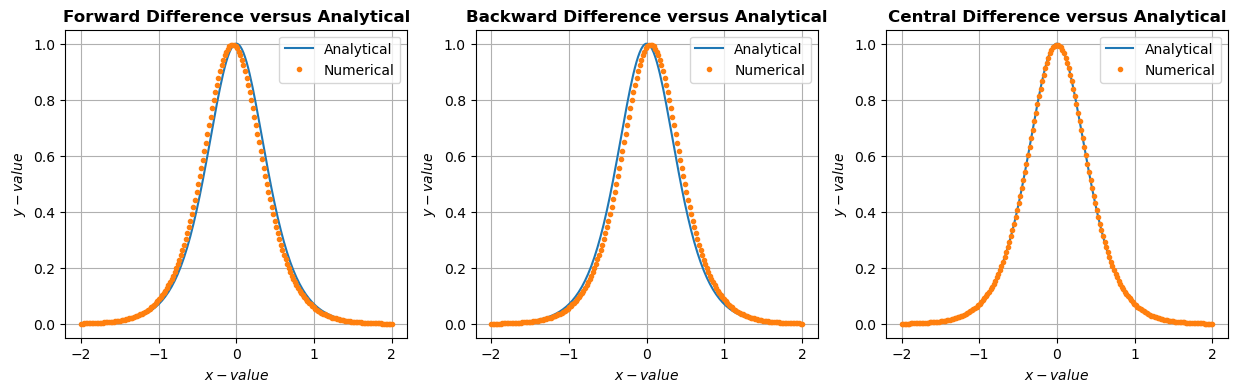

In [37]:
import matplotlib.pyplot as plt

def f_prime(x):
    y = 1 / (np.cosh(2*x) ** 2)
    return y

h = 0.1
xs = np.linspace(-2, 2, 200)
functions = [for_diff, back_diff, cen_diff]
function_names = ['Forward Difference', 'Backward Difference', 'Central Difference']

plt.figure(figsize=(15, 4))

for input, function in enumerate(functions):
    plt.subplot(1, 3, input+1)
    plt.plot(xs, f_prime(xs), label='Analytical')
    plt.plot(xs, function(f, xs, h), '.', label='Numerical')
    plt.title(f"{function_names[input]} versus Analytical", fontweight='bold')
    plt.xlabel('$x-value$')
    plt.ylabel('$y-value$')
    plt.legend()
    plt.grid()

plt.show()

#### Problem 1 Code Summary

The above code defines functions corresponding to different numerical formulas for evaluating derivatives and plots them against the analytical functions. Since there were many functions to plot, a for loop was used for concise code and efficient plotting.

### Problem 2: Simple Harmonic Oscillator

The position $x(t)$ of a 1D simple harmonic oscillator is described by the equation of motion:

$$-kx = \frac{d^2x}{dt^2}$$

We know a solution can take the form of $x(t) = \cos(t)$. Calculate the velocity of this particle using any finite-difference method, and plot its absolute error with respect to the analytical value by varying your step-sizes. The absolute error should have the same trend as the $\mathcal{O}$ error of your chosen method.

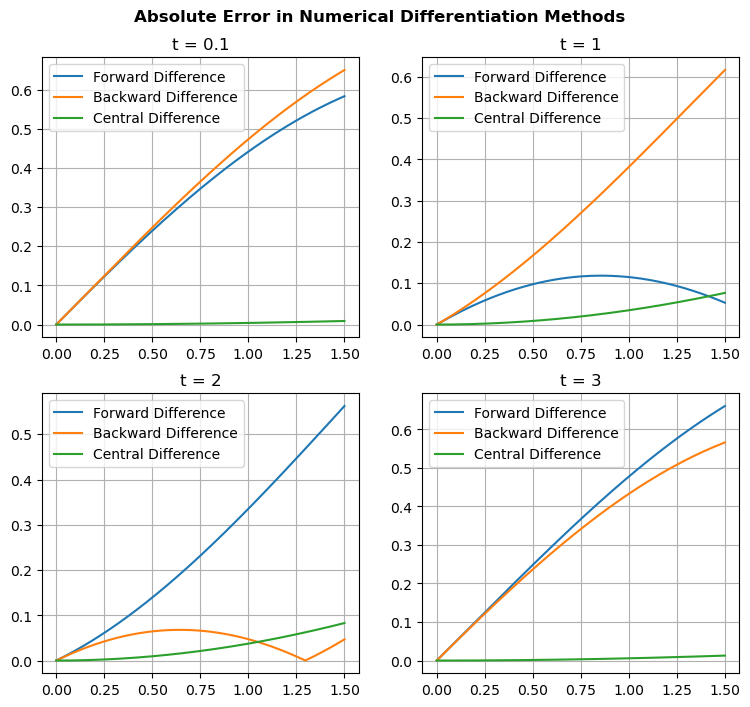

In [36]:
hs = np.linspace(10**(-10), 1.5, 200)
t_values = [0.1, 1, 2, 3]

plt.figure(figsize=(9, 8))

for input, t in enumerate(t_values):
    
    plt.subplot(2, 2, input+1)
    
    for input, function in enumerate(functions):
        error = abs( -np.sin(t) - function(np.cos, t, hs) )
        plt.plot(hs, error, label=f"{function_names[input]}")
        plt.title(f"t = {t}")
        plt.legend()
        plt.grid()

plt.suptitle('Absolute Error in Numerical Differentiation Methods', fontsize=12, fontweight='bold', y=0.94)
plt.show()



#### Problem 2 code summary

The above code plots the absolute error of different numerical differentiation formulas from the analytical value. Similarly to Problem 1, a for loop was used to efficiently ans concisely plot the three error lines.

---
## Section 3: Tutorials

### Derivatives

The derivate of a function $f(x) $ can be approximated using the **forward difference** as

$$f'(x) = \frac{f(x+h) - f(x)}{h} + \mathcal{O}(h)$$

using the **backward difference**

$$f'(x) = \frac{f(x) - f(x-h)}{h} + \mathcal{O}(h)$$

and the **central difference**

$$f'(x) = \frac{f(x + \frac{h}{2}) - f(x - \frac{h}{2})}{h} + \mathcal{O}(h^2)$$

where $h$ is a small step-size. To minimzie error, you can use Richardson Extrapolation, which can be found on the book (Gezerlis).

### Floating-point representation

Python uses 64-bit float by default for any number you type in with a decimal point. Different floating point precision can be used at a lower level, which we can go around by using [Numpy dtypes](https://numpy.org/doc/stable/reference/arrays.dtypes.html). 

Useful links:
* [(Goldberg, 1991) *What every computer scientist should know about floating-point arithmetic*](https://dl.acm.org/doi/10.1145/103162.103163)
* [Wikipedia - Floating-point arithmetic](https://en.wikipedia.org/wiki/Floating-point_arithmetic)
* [Data types - NumPy](https://numpy.org/doc/stable/user/basics.types.html)
* [decimal — Decimal fixed-point and floating-point arithmetic](https://docs.python.org/3/library/decimal.html)
* [fractions — Rational numbers](https://docs.python.org/3/library/fractions.html)

In [7]:
import matplotlib.pyplot as plt
import numpy as np

from decimal import Decimal
from fractions import Fraction

# Classic floating point quirks example
print(0.1 + 0.2)

# How about increasing precision?
print(np.float128(0.1) + np.float128(0.2))

# How bad is decreasing precision?
print(np.float16(0.1) + np.float16(0.2))

# Closest we could get to fixed-point arithmetic: decimal
print(Decimal(0.1) + Decimal(0.2))

# How about using an explicit Fraction object type?
print(float(Fraction(1, 10) + Fraction(1, 5)))

0.30000000000000004
0.30000000000000001665
0.2998
0.3000000000000000166533453694
0.3


### Basics

In [9]:
x = 0.5 # floats
y = 1 # integer
z = 'Hello' # string

x, y = y, x # swapping variables
a, b = 2, 3 # multiple assignments
print(x)
print(y)

1
0.5


In [10]:
x + y # sum
x - y # difference
x * y # multiplication
x / y # division
x // y # floor division
x % y # modulo
x ** y # power

1.0

### Control flow

In [11]:
x = 0

if x!= 0:
    print("x is nonzero")
elif x==0:
    print("x is zero")

x is zero


In [12]:
y = 25
if (y%5==0) == True:
    print('y is divisible by 5')

y is divisible by 5


In [13]:
# you can write truthiness conditionals more succinctly as 
# if condition is True, mathematically a True equals 1.0 while a False equals 0.0
if not (y%5):
    print('y is divisible by 5')

y is divisible by 5


In [14]:
for i in range(1,15,2):
    print(0.01*i, end=" ") # the end=" " syntax tells the value shall be printed in line

0.01 0.03 0.05 0.07 0.09 0.11 0.13 

### Data structures

In [15]:
xs = []
for i in range(20):
    xs.append(0.1*i)

# BE CAREFUL!!!
# list is different from array
list1 = [1, 2, 3]
list2 = [4, 5, 6]
list1 + list2 # concatenates

[1, 2, 3, 4, 5, 6]

In [16]:
list1 = np.array([1, 2, 3])
list2 = np.array([4, 5, 6])
list1 + list2 # adds element-wise!

array([5, 7, 9])

In [17]:
# Tuples are primarily used to bundle related pieces of data together, 
# protect data from accidental modification, and optimize performance.

tuple1 = (1, 2, 3)
tuple1[1]  # can be indexed just like lists

2

In [18]:
# strings can also be indexed like numbers

name = "Wilson"
name[0]

'W'

In [19]:
# string dot format arguments

x, y = 3.1, - 2.5
"{0:1.15f} {1:1.0f}".format(x, y) 

# the general string format looks like "{2} {0} {1}".format(a, b, c)
# the number inside the curly brackets contain the index of the variables inside the format( ... )
# you can modify the numbers outputted by specifiying the datatype inside the curly bracket 
# {0:1.15f} means print the zeroth number and print the number as a float with 15 decimal places 
# {1: 1.0f} means print the 1st number (second actually) and print as a float with 0 decimal places

'3.100000000000000 -2'

In [20]:
# slicing a list creates a new list

xs = [1, 2, 3]
ys = xs[1:] # the square bracket after a list corresponds to index (start:end) ... (start:end:interval)
zs = xs[:] # [:] means copy everything --> create an exact (shallow) copy of xs
print(xs)
print(ys)

# shallow copy duplicates an object's top-level properties 
# but keeps references to any nested objects, meaning changes to nested data affect the original. 
# A deep copy fully clones all levels and nested structures,
# creating a completely independent duplicate where changes do not affect the original.

[1, 2, 3]
[2, 3]


In [21]:
import copy
from copy import deepcopy

original = [1, 2, [3, 4]] # notice the list inside a list
shallow_copied = original[:]

# modifying a top-level element
shallow_copied[0] = 99
print("After modifying top-level element:")
print(f"Original: {original}")        
print(f"Copied:   {shallow_copied}")  

# modifying a nested mutable element
shallow_copied[2][0] = "changed" 
print("\nAfter modifying nested element (SHALLOW):") # BTW \n in string means paragraph break
print(f"Original: {original}")        
print(f"Copied:   {shallow_copied}")  

deep_copied = deepcopy(original)
original = [1, 2, [3, 4]]
deep_copied[2][0] = "changed" 
print("\nAfter modifying nested element (DEEP COPIED):") # BTW \n in string means paragraph break
print(f"Original: {original}")        
print(f"Copied:   {deep_copied}")  

After modifying top-level element:
Original: [1, 2, [3, 4]]
Copied:   [99, 2, [3, 4]]

After modifying nested element (SHALLOW):
Original: [1, 2, ['changed', 4]]
Copied:   [99, 2, ['changed', 4]]

After modifying nested element (DEEP COPIED):
Original: [1, 2, [3, 4]]
Copied:   [1, 2, ['changed', 4]]


In [22]:
# dictionaries

htow = {1.41: 31.3, 1.45: 36.7, 1.48: 42.4} # is a dictionary associating heights to weights
# each entry is separated by a comma,
# each entry is composed of keys and items
# the first key is 1.41 with corresponding 31.3 item

for key, item in htow.items():
    print(f'key is {key} with item {item}')

# dictionaries are pretty useful for collecting a parallel set of content
# you can use strings as keys too

key is 1.41 with item 31.3
key is 1.45 with item 36.7
key is 1.48 with item 42.4


### User-defined functions

In [23]:
# start with def<space>name_of_your_function(input, parameters):
# end with return
# once a function encounters return, it ends all operations and sends the value back to the caller

def sumofints(nmax):
    val = sum(range(1,nmax+1))
    return val

# use the above function as
x = sumofints(42)
print(x)

# you could have multiple inputs and outputs
# functions can also return multiple values (effectively the output is a tuple for such cases)

903


In [33]:
from math import cos

def cosder(x, h=0.01): # here h is a default parameter (meaning it already has a preset value)
    return (cos(x+h) - cos(x))/h

#You can call this function with either 
cosder(0.)
#or 
cosder(0., 0.001)
#ie the 2nd argument is optional

-0.0004999999583255033

In [25]:
# you can also pass functions as inputs
def der(f, x, h=0.01):
    return (f(x+h) - f(x))/h

### List comprehensions

"Using such alternative syntax to make the code more concise and ex-
pressive helps us write new programs, but also makes the lives of future readers easier. Of
course, you do have to exercise your judgement."

In [34]:
def f(x):
    return x//2

xs = [0.1*i for i in range(20)] 
ys = [2*x for x in xs] # multiplication operation with a list
ws = [f(x) for x in xs] # evaluating a function with elements of a list
zs = [2*x for x in xs if x>0.3] # pruning a list

### Basic plotting

- We will utilize NumPy and Matplotlib for most of our visualization
    - `import numpy as np` # Docs: https://numpy.org/doc/stable/reference/
    - `import matplotlib.pyplot as plt` # Docs: https://matplotlib.org/stable/api/pyplot_summary.html
  
- We will use Seaborn only to make the defaults look pretty.
- Our focus is to make plotting as flexible as possible.
- Check out its documentation if you're interested with its convenience features.
    - `import seaborn as sns` # Guide: https://seaborn.pydata.org/tutorial/introduction.html
    `sns.set_theme(style="darkgrid")`

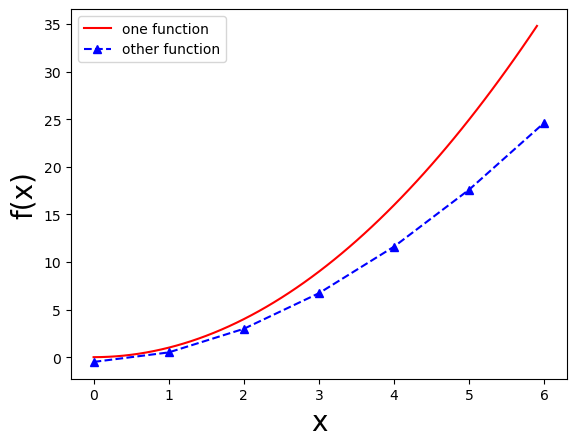

In [27]:
import matplotlib.pyplot as plt

def plotex(cxs,cys,dxs,dys):
    plt.xlabel('x', fontsize=20)
    plt.ylabel('f(x)', fontsize=20)
    plt.plot(cxs, cys, 'r-', label='one function')
    plt.plot(dxs, dys, 'b--^', label='other function')
    plt.legend()
    plt.show()

cxs = [0.1*i for i in range(60)]
cys = [x**2 for x in cxs]
dxs = [i for i in range(7)]
dys = [x**1.8 - 0.5 for x in dxs]

plotex(cxs, cys, dxs, dys)

<ErrorbarContainer object of 3 artists>

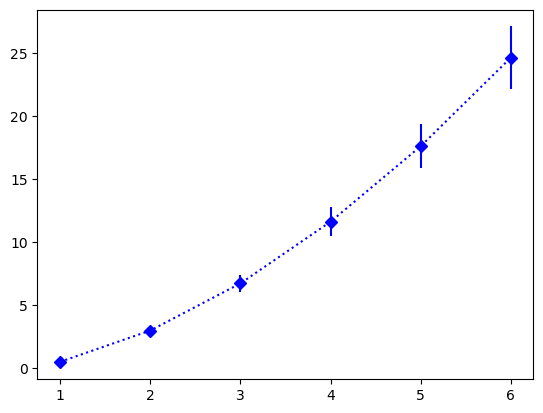

In [29]:
dyerrs = [0.1*y for y in dys]
plt.errorbar(dxs[1:], dys[1:], dyerrs[1:], fmt='b:D', label='with errors')

### NumPy idioms

<img src="figures/gezerlisTable1_2.png" width="67%">

In [30]:
import numpy as np

# for parallel computations: contribs = [w*f(x) for w,x in zip(ws,xs)]

zs = np.array([5, 8], dtype=np.float32) # converts contribs into a NumPy array
A, B, C = np.zeros(5), np.ones(4), np.arange(6)

print(A)
print(B)
print(C)

[0. 0. 0. 0. 0.]
[1. 1. 1. 1.]
[0 1 2 3 4 5]


In [31]:
# you can specify set of points

np.linspace(1, 10, 6) # 6 linearly spaced points from 1 to 10 (including 1 and 10)
np.arange(1, 10, 6) # from 1 to 10 in steps of 6
np.logspace(1, 10, 6) # 6 logarithmically spaced points from 1 to 10

# if you're not sure what to input, you can always shift+Tab inside the parenthesis to check the arguments

array([1.00000000e+01, 6.30957344e+02, 3.98107171e+04, 2.51188643e+06,
       1.58489319e+08, 1.00000000e+10])